# Método dos Elementos Finitos (MEF)

O **MEF** (*FEM — Finite Element Method*) resolve EDPs **dividindo o domínio em
subdomínios pequenos e simples** — os **elementos finitos** — sobre os quais a
solução é aproximada por **funções de forma** (polinômios) simples.
Diferente do MDF (que discretiza a *equação*), o MEF discretiza o *domínio* e é
naturalmente adequado a **geometrias irregulares**.

## Etapas do método

1. **Discretização (malha):** o domínio 2D é dividido em **elementos triangulares**.
   Cada triângulo tem 3 **nós** com coordenadas $(x, y)$.

2. **Funções de forma:** dentro de cada elemento, o potencial é aproximado por uma
   interpolação **linear** entre os valores nodais:
   $\phi(x,y) \approx \sum_{i=1}^{3} \alpha_i \phi_i$.

3. **Matriz de rigidez do elemento:** minimizando o **funcional de energia**
   associado à equação de Laplace, obtém-se a matriz local

   $$
   C^{(e)}_{ij} = \frac{P_i P_j + Q_i Q_j}{4\,A}
   $$

   onde $A$ é a **área** do triângulo e $P_i, Q_i$ dependem das coordenadas dos nós
   (são as derivadas das funções de forma).

4. **Montagem global (assembly):** as matrizes de todos os elementos são somadas
   nas posições corretas, formando a **matriz de rigidez global** $[C]$.

5. **Condições de contorno:** nós com **potencial preestabelecido** (Dirichlet)
   têm suas linhas fixadas e suas contribuições passadas para o vetor do lado
   direito $[B]$.

6. **Resolução:** resolve-se o sistema $[C]\,[V] = [B]$. O script verifica o
   **condicionamento** da matriz e, se necessário, usa **SVD** ou **pseudo-inversa**
   para garantir robustez.

> **No script:** resolve-se a equação de Laplace 2D numa malha triangular,
> exibindo a distribuição de potencial em mapa de contorno, a malha de elementos
> e uma superfície 3D.

**Elementos finitos**

SOLUÇÃO DA EQUAÇÃO DE LAPLACE POR ELEMENTOS FINITOS
Usando dados padrão...
Número de nós (ND): 21
Número de elementos (NE): 25
Número de nós fixos (NP): 15

Calculando matriz de rigidez global...
Resolvendo sistema de equações...
Rank(Posto) da matriz: 21/21
Número de condicionamento: 6.24e+00
Determiante da matriz: 2.64e+03
Sistema resolvido com sucesso!

RESULTADOS
Nó  1: X=0.000, Y=0.000, V=0.000000
Nó  2: X=0.200, Y=0.000, V=0.000000
Nó  3: X=0.400, Y=0.000, V=0.000000
Nó  4: X=0.600, Y=0.000, V=0.000000
Nó  5: X=0.800, Y=0.000, V=0.000000
Nó  6: X=1.000, Y=0.000, V=50.000000
Nó  7: X=0.000, Y=0.200, V=0.000000
Nó  8: X=0.200, Y=0.200, V=18.181818
Nó  9: X=0.400, Y=0.200, V=36.363636
Nó 10: X=0.600, Y=0.200, V=59.090909
Nó 11: X=0.800, Y=0.200, V=100.000000
Nó 12: X=0.000, Y=0.400, V=0.000000
Nó 13: X=0.200, Y=0.400, V=36.363636
Nó 14: X=0.400, Y=0.400, V=68.181818
Nó 15: X=0.600, Y=0.400, V=100.000000
Nó 16: X=0.000, Y=0.600, V=0.000000
Nó 17: X=0.200, Y=0.600, V=59.090909
Nó 18: 

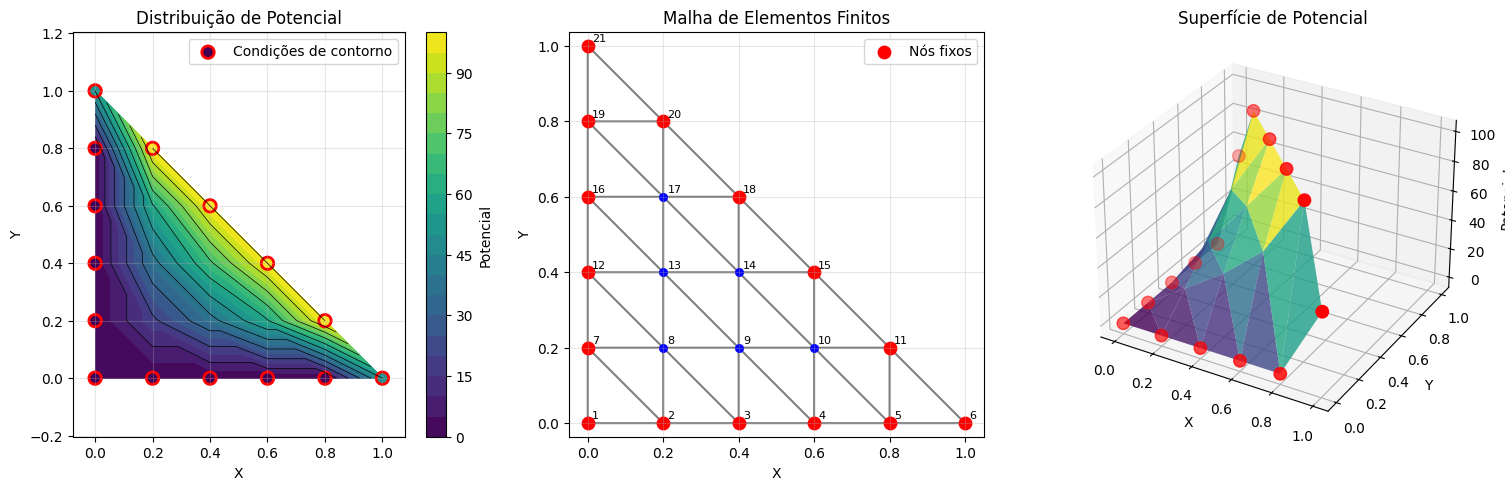

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import sys

def fem_laplace_solver():
    """
    SOLUÇÃO DA EQUAÇÃO DE LAPLACE POR ELEMENTOS FINITOS
    PARA PROBLEMAS BIDIMENSIONAIS
    USANDO ELEMENTOS TRIANGULARES

    ND = Nº DE NÓS
    NE = Nº DE ELEMENTOS
    NP = Nº DE NÓS FIXOS (ONDE O POTENCIAL É PREESTABELECIDO)
    NDP(I) = Nº DO NÓ COM POTENCIAL PREESTABELECIDO, I=1,2,...,NP
    VAL(I) = VALOR DO POTENCIAL PREESTABELECIDO NO NÓ NDP(I)
    NL(I,J) = LISTA DOS NÓS PARA CADA ELEMENTO I, ONDE
    J:1,2,3 REFERE-SE AO NÚMERO DO NÓ LOCAL
    CE(I,J) = MATRIZ DE COEFICIENTES DO ELEMENTO
    C(I,J)  = MATRIZ DE RIGIDEZ GLOBAL
    B(I)    = MATRIZ DO LADO DIREITO NO SISTEMA DE EQUAÇÕES SIMULTÂNEAS
    X(I), Y(I) = COORDENADAS GLOBAIS DO NÓ I
    XL(J), YL(J) = COORDENADAS LOCAIS DO NÓ J=1,2,3
    V(I) = POTENCIAL NO NÓ I
    MATRIZES P(I) E Q(I) ESTÃO DEFINIDAS NA EQUAÇÃO (15.62a)
    """

    # *********************************************************
    # PRIMEIRA ETAPA - DADOS DE ENTRADA
    # *********************************************************

    print("SOLUÇÃO DA EQUAÇÃO DE LAPLACE POR ELEMENTOS FINITOS")
    print("="*50)

    filename = input("Nome do arquivo de dados de entrada (ou pressione Enter para usar dados padrão): ")

    if filename.strip() == "":
        print("Usando dados padrão...")

        ND = 21  # Número de nós
        NE = 25  # Número de elementos

        X = np.array([
            0.0, 0.2, 0.4, 0.6, 0.8, 1.0,  # linha y=0
            0.0, 0.2, 0.4, 0.6, 0.8,        # linha y=0.2
            0.0, 0.2, 0.4, 0.6,             # linha y=0.4
            0.0, 0.2, 0.4,                  # linha y=0.6
            0.0, 0.2,                       # linha y=0.8
            0.0                             # linha y=1.0
        ])

        Y = np.array([
            0.0, 0.0, 0.0, 0.0, 0.0, 0.0,  # linha y=0
            0.2, 0.2, 0.2, 0.2, 0.2,        # linha y=0.2
            0.4, 0.4, 0.4, 0.4,             # linha y=0.4
            0.6, 0.6, 0.6,                  # linha y=0.6
            0.8, 0.8,                       # linha y=0.8
            1.0                             # linha y=1.0
        ])

        NL = np.array([
            [1, 2, 7],   [2, 8, 7],   [2, 3, 8],   [3, 9, 8],   [3, 4, 9],
            [4, 10, 9],  [4, 5, 10],  [5, 11, 10], [5, 6, 11],  [7, 8, 12],
            [8, 13, 12], [8, 9, 13],  [9, 14, 13], [9, 10, 14], [10, 15, 14],
            [10, 11, 15],[12, 13, 16],[13, 17, 16], [13, 14, 17],[14, 18, 17],
            [14, 15, 18],[16, 17, 19],[17, 20, 19], [17, 18, 20],[19, 20, 21]
        ], dtype=int) - 1  # ajuste para indexação base-0

        NP  = 15
        NDP = np.array([1, 2, 3, 4, 5, 6, 11, 15, 18, 20, 21, 19, 16, 12, 7], dtype=int) - 1
        VAL = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 50.0,
                        100.0, 100.0, 100.0, 100.0, 50.0,
                        0.0, 0.0, 0.0, 0.0])

    else:
        try:
            data = np.loadtxt(filename)
            print(f"Carregando dados do arquivo: {filename}")
        except FileNotFoundError:
            print(f"Arquivo {filename} não encontrado. Usando dados padrão.")
            return fem_laplace_solver()

    print(f"Número de nós (ND): {ND}")
    print(f"Número de elementos (NE): {NE}")
    print(f"Número de nós fixos (NP): {NP}")

    # *********************************************************
    # SEGUNDA ETAPA - MATRIZ DE RIGIDEZ GLOBAL
    # *********************************************************

    print("\nCalculando matriz de rigidez global...")

    B = np.zeros(ND)
    C = np.zeros((ND, ND))

    for I in range(NE):
        K  = NL[I, :]
        XL = X[K]
        YL = Y[K]

        P = np.zeros(3)
        Q = np.zeros(3)

        P[0] = YL[1] - YL[2]
        P[1] = YL[2] - YL[0]
        P[2] = YL[0] - YL[1]

        Q[0] = XL[2] - XL[1]
        Q[1] = XL[0] - XL[2]
        Q[2] = XL[1] - XL[0]

        AREA = 0.5 * abs(P[1] * Q[2] - Q[1] * P[2])

        if AREA <= 0:
            print(f"Aviso: Elemento {I+1} tem área não positiva: {AREA}")
            continue

        CE = (np.outer(P, P) + np.outer(Q, Q)) / (4.0 * AREA)

        for J in range(3):
            IR     = NL[I, J]
            IFLAG1 = 0

            for K in range(NP):
                if IR == NDP[K]:
                    C[IR, IR] = 1.0
                    B[IR]     = VAL[K]
                    IFLAG1    = 1
                    break

            if IFLAG1 == 0:
                for L in range(3):
                    IC     = NL[I, L]
                    IFLAG2 = 0

                    for K in range(NP):
                        if IC == NDP[K]:
                            B[IR]  = B[IR] - CE[J, L] * VAL[K]
                            IFLAG2 = 1
                            break

                    if IFLAG2 == 0:
                        C[IR, IC] = C[IR, IC] + CE[J, L]

    # *********************************************************
    # TERCEIRA ETAPA - RESOLUÇÃO DO SISTEMA
    # *********************************************************

    print("Resolvendo sistema de equações...")

    rank         = np.linalg.matrix_rank(C)
    cond_num     = np.linalg.cond(C)
    determinante = np.linalg.det(C)

    print(f"Rank(Posto) da matriz: {rank}/{ND}")
    print(f"Número de condicionamento: {cond_num:.2e}")
    print(f"Determiante da matriz: {determinante:.2e}")

    try:
        if cond_num > 1e12:
            print("Matriz mal condicionada, usando decomposição SVD...")
            U, s, Vt = np.linalg.svd(C)
            s_inv    = np.where(s > 1e-12, 1/s, 0)
            C_pinv   = Vt.T @ np.diag(s_inv) @ U.T
            V        = C_pinv @ B
        else:
            V = np.linalg.solve(C, B)
        print("Sistema resolvido com sucesso!")
    except np.linalg.LinAlgError as e:
        print(f"Erro na resolução: {e}")
        print("Usando pseudo-inversa...")
        V = np.linalg.pinv(C) @ B

    # *********************************************************
    # QUARTA ETAPA - SAÍDA DOS RESULTADOS
    # *********************************************************

    print("\n" + "="*50)
    print("RESULTADOS")
    print("="*50)

    with open('exemplo_fem.out', 'w') as f:
        f.write(f"Número de nós (ND): {ND}\n")
        f.write(f"Número de elementos (NE): {NE}\n")
        f.write(f"Número de nós fixos (NP): {NP}\n\n")
        f.write("Nó\tX\t\tY\t\tPotencial\n")
        f.write("-" * 40 + "\n")

        for i in range(ND):
            f.write(f"{i+1}\t{X[i]:.3f}\t\t{Y[i]:.3f}\t\t{V[i]:.6f}\n")
            print(f"Nó {i+1:2d}: X={X[i]:.3f}, Y={Y[i]:.3f}, V={V[i]:.6f}")

    print(f"\nResultados salvos em: exemplo_fem.out")
    print(f"\nEstatísticas da solução:")
    print(f"Potencial mínimo: {V.min():.6f}")
    print(f"Potencial máximo: {V.max():.6f}")
    print(f"Potencial médio:  {V.mean():.6f}")

    plot_results(X, Y, NL, V, NDP, VAL)

    return X, Y, V, NL, NDP, VAL


def plot_results(X, Y, NL, V, NDP, VAL):
    """Função para plotar os resultados"""

    triang = Triangulation(X, Y, NL)

    plt.figure(figsize=(15, 5))

    # Subplot 1: Contornos preenchidos
    plt.subplot(1, 3, 1)
    contour_filled = plt.tricontourf(triang, V, levels=20, cmap='viridis')
    plt.colorbar(contour_filled, label='Potencial')
    plt.tricontour(triang, V, levels=10, colors='k', linewidths=0.5)
    plt.scatter(X[NDP], Y[NDP], c=VAL, cmap='viridis', s=80,
                edgecolors='red', linewidth=2, label='Condições de contorno')
    plt.title("Distribuição de Potencial")
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Malha
    plt.subplot(1, 3, 2)
    plt.triplot(triang, 'k-', alpha=0.5)
    plt.scatter(X, Y, c='blue', s=30)
    for i in range(len(X)):
        plt.annotate(f'{i+1}', (X[i], Y[i]), xytext=(3, 3),
                     textcoords='offset points', fontsize=8)
    plt.scatter(X[NDP], Y[NDP], c='red', s=80, label='Nós fixos')
    plt.title("Malha de Elementos Finitos")
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 3: Gráfico 3D
    ax = plt.subplot(1, 3, 3, projection='3d')
    ax.plot_trisurf(X, Y, V, triangles=NL, cmap='viridis', alpha=0.8)
    ax.scatter(X[NDP], Y[NDP], VAL, c='red', s=80, label='Condições de contorno')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Potencial')
    ax.set_title('Superfície de Potencial')

    plt.tight_layout()
    plt.show()


# Executar o programa principal
if __name__ == "__main__":
    try:
        X, Y, V, NL, NDP, VAL = fem_laplace_solver()
    except KeyboardInterrupt:
        print("\nPrograma interrompido pelo usuário.")
    except Exception as e:
        print(f"Erro durante a execução: {e}")
        import traceback
        traceback.print_exc()
